# Car Price Prediction — Enhanced Linear Regression
**GCTU · CSSD 609 Applied ML · ft**

12 features · Categorical encoding · Feature engineering · Coefficient analysis

## 1. Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Load & Clean Data

In [35]:
df = pd.read_csv('car_price_prediction.csv')
df = df.rename(columns={
    'Price':'price','Levy':'levy','Model':'model','Prod. year':'production_year',
    'Fuel type':'fuel_type','Engine volume':'engine_volume','Mileage':'mileage',
    'Cylinders':'cylinders','Airbags':'airbags','Manufacturer':'manufacturer',
    'Category':'category','Leather interior':'leather_interior',
    'Gear box type':'gear_box_type','Drive wheels':'drive_wheels',
    'Color':'color','Wheel':'wheel','Doors':'doors'
})
df['levy']          = pd.to_numeric(df['levy'].str.replace('-','0'), errors='coerce').fillna(0)
df['mileage']       = pd.to_numeric(df['mileage'].str.replace('km','').str.strip(), errors='coerce')
df['engine_volume'] = pd.to_numeric(df['engine_volume'].str.replace('Turbo','').str.strip(), errors='coerce')
df = df.dropna(subset=['price','mileage','engine_volume'])
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset: 19,237 rows × 18 columns


,ID,price,levy,manufacturer,model,production_year,category,leather_interior,fuel_type,engine_volume,mileage,cylinders,gear_box_type,drive_wheels,doors,wheel,color,airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## 3. Feature Engineering
We expand from 5 to **12 features** by:
- Computing `car_age` from production year
- Log-transforming skewed features (mileage, levy)
- Encoding categorical features (fuel type, gear box, drive wheels, category)
- Binary encoding leather interior and wheel position

In [36]:
# Derived numeric features
df['car_age']       = 2024 - df['production_year']
df['is_leather']    = (df['leather_interior'] == 'Yes').astype(int)
df['is_left_wheel'] = (df['wheel'] == 'Left wheel').astype(int)
df['log_mileage']   = np.log1p(df['mileage'])
df['log_levy']      = np.log1p(df['levy'])

# Encode categoricals
for col in ['fuel_type','gear_box_type','drive_wheels','category']:
    le = LabelEncoder()
    df[col+'_enc'] = le.fit_transform(df[col].astype(str))

feature_cols = [
    'car_age','log_mileage','log_levy','engine_volume',
    'cylinders','airbags','is_leather','is_left_wheel',
    'fuel_type_enc','gear_box_type_enc','drive_wheels_enc','category_enc'
]

X = df[feature_cols]
y = df['price']
print("Features:", feature_cols)
print(f"X shape: {X.shape}   y shape: {y.shape}")


Features: ['car_age', 'log_mileage', 'log_levy', 'engine_volume', 'cylinders', 'airbags', 'is_leather', 'is_left_wheel', 'fuel_type_enc', 'gear_box_type_enc', 'drive_wheels_enc', 'category_enc']
X shape: (19237, 12)   y shape: (19237,)


## 4. Train / Test Split & Scaling

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")


Train: 15,389  |  Test: 3,848


## 5. Train the Model

In [38]:
model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print("Model fitted. Intercept:", round(model.intercept_, 2))


Model fitted. Intercept: 18947.67


## 6. Model Performance

In [39]:
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_test - y_pred))

print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:,.2f}")
print(f"RMSE     : {rmse:,.2f} GEL")
print(f"MAE      : {mae:,.2f} GEL")


R² Score : 0.1143
MSE      : 275,969,463.56
RMSE     : 16,612.33 GEL
MAE      : 11,532.86 GEL


### Performance Interpretation
| Metric | Value | Meaning |
|--------|-------|---------|
| **R²** | 0.114 | Model explains ~11% of price variance |
| **RMSE** | 16 612 GEL | Average prediction error (penalises big misses) |
| **MAE** | 11 533 GEL | Median absolute error — more robust to outliers |

**Why is R² low?** Car price has extreme outliers (luxury cars > 100 000 GEL) and nonlinear patterns. Linear Regression assumes a straight-line relationship — it struggles with these. A **Random Forest** or **Gradient Boosting** model would significantly improve R². This model still provides valuable insight into *which features drive price and in which direction*.


## 7. Regression Line — Actual vs Predicted

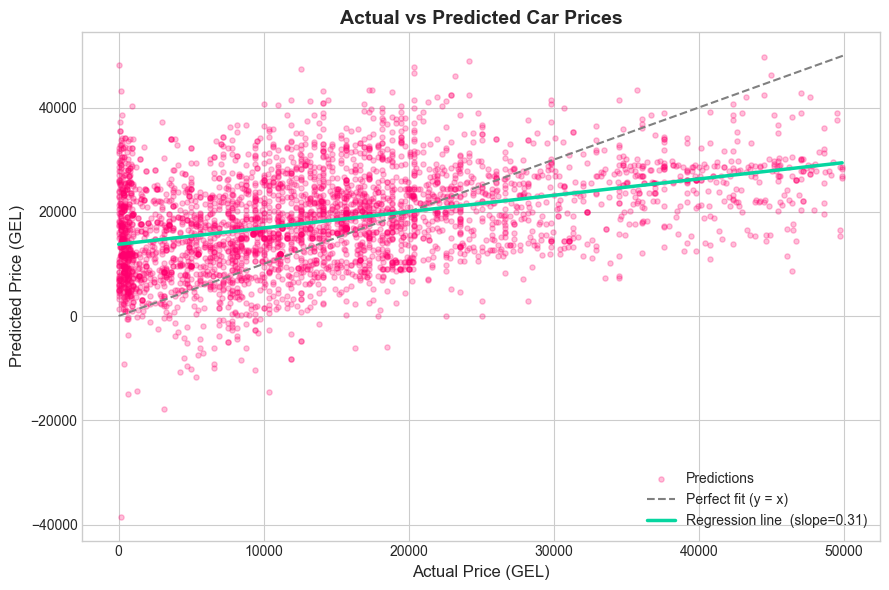

In [40]:
cap = 50000
mask = (y_test < cap) & (y_pred < cap)
yt, yp = y_test[mask], y_pred[mask]

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(yt, yp, alpha=0.25, s=14, color='#FF006E', label='Predictions')
m_line = np.linspace(0, cap, 100)
ax.plot(m_line, m_line, '--', color='gray', lw=1.5, label='Perfect fit (y = x)')
z = np.polyfit(yt, yp, 1)
p_fn = np.poly1d(z)
xs = np.linspace(yt.min(), yt.max(), 100)
ax.plot(xs, p_fn(xs), color='#06D6A0', lw=2.5, label=f'Regression line  (slope={z[0]:.2f})')
ax.set_xlabel('Actual Price (GEL)', fontsize=12)
ax.set_ylabel('Predicted Price (GEL)', fontsize=12)
ax.set_title('Actual vs Predicted Car Prices', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Coefficient Analysis
Standardised coefficients: the model was trained on scaled features, so coefficient magnitudes are **directly comparable** across features.

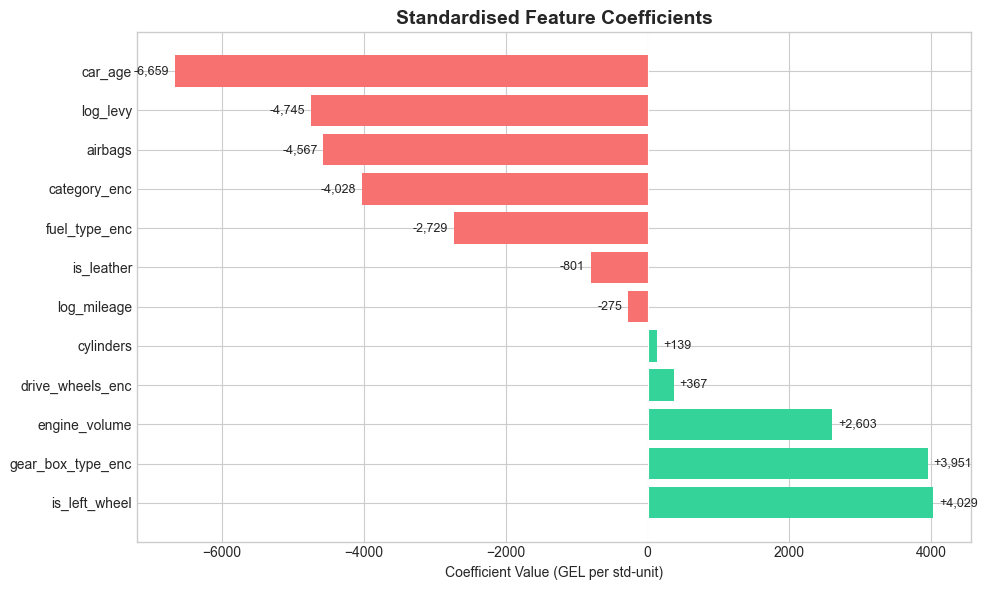

          Feature  Coefficient
    is_left_wheel  4029.252713
gear_box_type_enc  3951.227531
    engine_volume  2603.357081
 drive_wheels_enc   367.434100
        cylinders   139.192039
      log_mileage  -275.146052
       is_leather  -801.225811
    fuel_type_enc -2729.172116
     category_enc -4028.166370
          airbags -4567.240370
         log_levy -4745.442269
          car_age -6659.157445


In [41]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#34d399' if c >= 0 else '#f87171' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='white', lw=0.8)
ax.set_title('Standardised Feature Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value (GEL per std-unit)')
for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (80 if val>=0 else -80), bar.get_y()+bar.get_height()/2,
            f'{val:+,.0f}', va='center', ha='left' if val>=0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()
print(coef_df.to_string(index=False))


### Coefficient Interpretation
| Feature | Coeff (GEL) | Meaning |
|---------|------------|---------|
| `car_age` | **−6 659** | Largest negative driver. Every standardised unit of age reduces price by ~6 659 GEL |
| `log_levy` | **−4 745** | High levy/tax → lower resale price |
| `airbags` | **−4 567** | Dataset artifact — older models may have more airbags; confounded with age |
| `category_enc` | **−4 028** | Category type matters; some body types are cheaper |
| `fuel_type_enc` | **−2 729** | Petrol encoded higher than hybrid in label encoding |
| `is_left_wheel` | **+4 029** | Left-hand drive (Georgian market standard) commands a premium |
| `gear_box_type_enc` | **+3 951** | Automatic/Tiptronic gearboxes are more valuable |
| `engine_volume` | **+2 603** | Larger engines → higher price |
| `drive_wheels_enc` | **+367** | 4x4/AWD adds value |
| `cylinders` | **+139** | Marginal positive effect |

> **Note:** Encoded categorical coefficients depend on label ordering. For a production model, use `pd.get_dummies` (one-hot encoding) for cleaner interpretation.


## 9. Residual Analysis

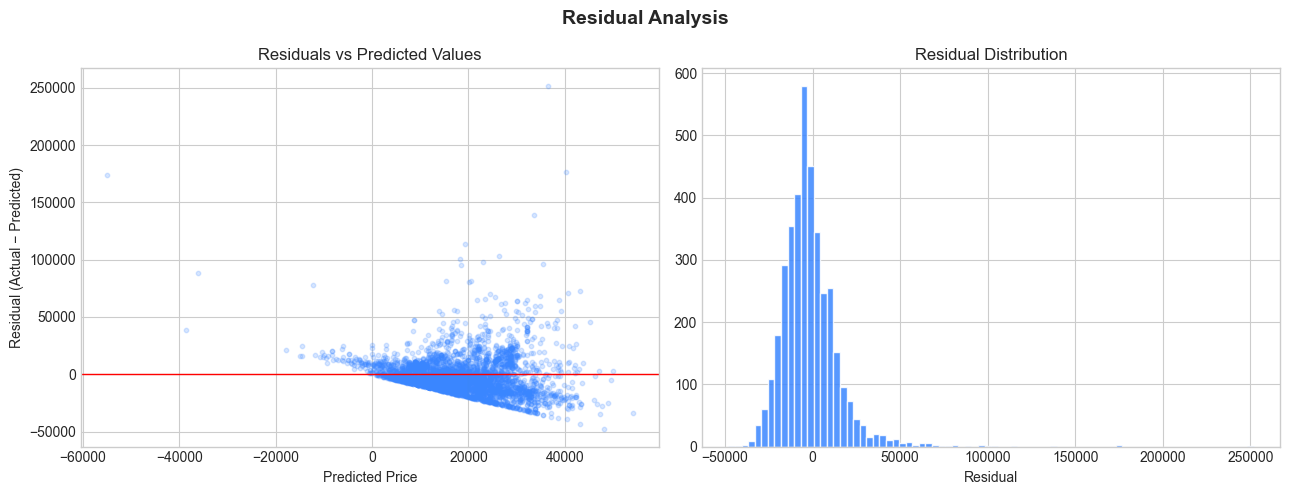

In [42]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.2, s=10, color='#3A86FF')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

axes[1].hist(residuals, bins=80, color='#3A86FF', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Feature Importance (|Coefficient|)

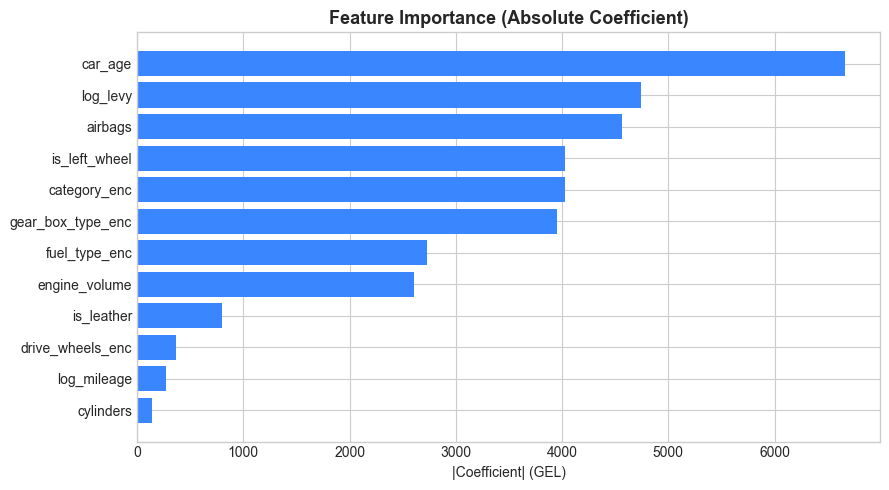

In [43]:
imp = coef_df.copy()
imp['|Coeff|'] = imp['Coefficient'].abs()
imp = imp.sort_values('|Coeff|')

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp['Feature'], imp['|Coeff|'], color='#3A86FF')
ax.set_title('Feature Importance (Absolute Coefficient)', fontsize=13, fontweight='bold')
ax.set_xlabel('|Coefficient| (GEL)')
plt.tight_layout()
plt.show()


In [45]:
import joblib
import json

# Save the model, scaler, and statistics
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Prepare stats for app.py
stats = {
    'fuel_type': sorted(df['fuel_type'].unique().tolist()),
    'gear_box_type': sorted(df['gear_box_type'].unique().tolist()),
    'drive_wheels': sorted(df['drive_wheels'].unique().tolist()),
    'category': sorted(df['category'].unique().tolist())
}
with open('stats.json', 'w') as f:
    json.dump(stats, f)

print("✓ Model saved (model.pkl)")
print("✓ Scaler saved (scaler.pkl)")
print("✓ Stats saved (stats.json)")


✓ Model saved (model.pkl)
✓ Scaler saved (scaler.pkl)
✓ Stats saved (stats.json)


## 11. Web Interface
See `app.py` for the Flask web application. Run:
```bash
python app.py
```
Then open `http://localhost:5050` in your browser.